### Etapa 3   


In [1]:
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd

In [2]:
df = pd. read_csv ("C:/Users/Cristina/Documents/Entrenamiento-IA-/classData detection failure.csv")

df.head()


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


In [3]:
# Conteo de valores nulos en toda la tabla
df.isnull().sum()

G     0
C     0
B     0
A     0
Ia    0
Ib    0
Ic    0
Va    0
Vb    0
Vc    0
dtype: int64

In [4]:
#para ver conjunto de datos vemos desviacion estandar min - max 
df. describe()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
count,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000,7861.000000
mean,0.432006,0.411271,0.555527,0.571429,13.721194,-44.845268,34.392394,-0.007667,0.001152,0.006515
std,0.495387,0.492095,0.496939,0.494903,464.741671,439.269195,371.107412,0.289150,0.313437,0.307897
min,0.000000,0.000000,0.000000,0.000000,-883.542316,-900.526951,-883.357762,-0.620748,-0.608016,-0.612709
25%,0.000000,0.000000,0.000000,0.000000,-119.802518,-271.845947,-61.034219,-0.130287,-0.159507,-0.215977
50%,0.000000,0.000000,1.000000,1.000000,2.042805,5.513317,-4.326711,-0.005290,0.001620,0.009281
75%,1.000000,1.000000,1.000000,1.000000,227.246377,91.194282,49.115141,0.111627,0.153507,0.239973
max,1.000000,1.000000,1.000000,1.000000,885.738571,889.868884,901.274261,0.595342,0.627875,0.600179


### verificamos columnas para ver cantidad total de columnas 

In [6]:
print(df.columns.tolist())
df.info()

['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
<class 'pandas.DataFrame'>
RangeIndex: 7861 entries, 0 to 7860
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       7861 non-null   int64  
 1   C       7861 non-null   int64  
 2   B       7861 non-null   int64  
 3   A       7861 non-null   int64  
 4   Ia      7861 non-null   float64
 5   Ib      7861 non-null   float64
 6   Ic      7861 non-null   float64
 7   Va      7861 non-null   float64
 8   Vb      7861 non-null   float64
 9   Vc      7861 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 614.3 KB


In [ ]:
df.isna().sum()
df.head()
# me devolvio lo mismo que en el inicio df = pd. read_csv ("C:/Users/Cristina/Documents/Entrenamiento-IA-/classData detection failure.csv")
# df.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


array([[<Axes: title={'center': 'G'}>, <Axes: title={'center': 'C'}>,
        <Axes: title={'center': 'B'}>],
       [<Axes: title={'center': 'A'}>, <Axes: title={'center': 'Ia'}>,
        <Axes: title={'center': 'Ib'}>],
       [<Axes: title={'center': 'Ic'}>, <Axes: title={'center': 'Va'}>,
        <Axes: title={'center': 'Vb'}>],
       [<Axes: title={'center': 'Vc'}>, <Axes: >, <Axes: >]], dtype=object)

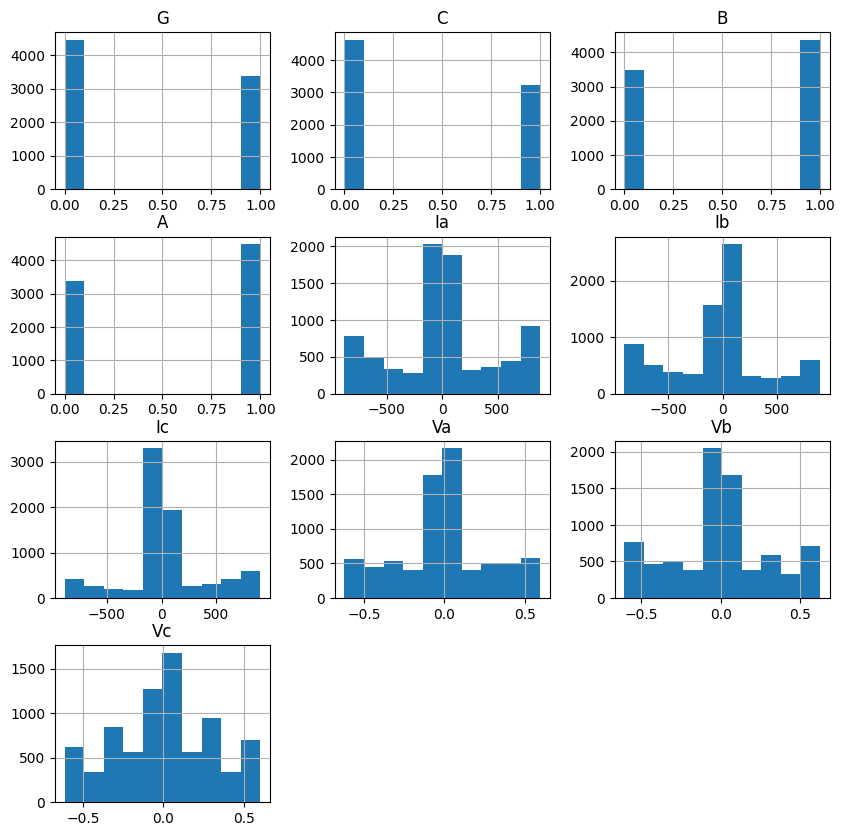

In [8]:
#realizar la 1º grafica de los datos 
df.hist(figsize=(10,10))

### vamos a tener que señalizar las columnas para trabajar con los armonicos del 2º,3º,5º,7º,13º

In [9]:
df.columns.tolist()


['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

In [10]:
#aplica una Transformada de Fourier (FFT)

import numpy as np

# FFT de la señal de corriente Ia
fft_Ia = np.fft.fft(df["Ia"])
freqs = np.fft.fftfreq(len(fft_Ia))

# Seleccionar armónicos específicos (2º, 3º, 5º, 7º, 13º)
armonicos = [2, 3, 5, 7, 13]
valores_armonicos = {n: np.abs(fft_Ia[n]) for n in armonicos}
print(valores_armonicos)


{2: np.float64(161635.9915105364), 3: np.float64(35685.50544728739), 5: np.float64(125833.84713110395), 7: np.float64(182843.96862215822), 13: np.float64(22736.589524041046)}


In [11]:
# Definir criterio de fallo 
def fallo_por_armonicos(row, armonicos_cols, umbral=50):
    for col in armonicos_cols:
        if abs(row[col]) > umbral:
            return 1
    return 0

df["Fallo_armonicos"] = df.apply(lambda r: fallo_por_armonicos(r, ["Ia","Ib","Ic","Va","Vb","Vc"]), axis=1)


In [13]:
df["Fallo_armonicos"].value_counts()


Fallo_armonicos
1    7135
0     726
Name: count, dtype: int64

### vamos a detectar si se desplaza el neutro usando la columna ground=G 

In [14]:
df["Suma_fases"] = df["A"] + df["B"] + df["C"]

df["Residuo"] = df["Suma_fases"] - df["G"]


In [15]:
umbral = 0.1  # ajustAR según magnitud típica de los datos empleados (puede cambiar)
df["Fallo_tierra"] = df["Residuo"].apply(lambda x: 1 if abs(x) > umbral else 0)

df["Fallo_tierra"].value_counts()


Fallo_tierra
1    4367
0    3494
Name: count, dtype: int64

### podemos crear para observar los picos de tension 

In [16]:
#ayuda a calcular entre  muestras consecutivas
df["dVa"] = df["Va"].diff()
df["dVb"] = df["Vb"].diff()
df["dVc"] = df["Vc"].diff()


### Definir umbral de pico

In [17]:
umbral_pico = 0.5  # ejemplo, ajustá según escala de tus tensiones
df["Pico_tension"] = (
    (df["dVa"].abs() > umbral_pico) |
    (df["dVb"].abs() > umbral_pico) |
    (df["dVc"].abs() > umbral_pico)
).astype(int)


In [18]:
#explorar resultado

df["Pico_tension"].value_counts()


Pico_tension
0    7857
1       4
Name: count, dtype: int64

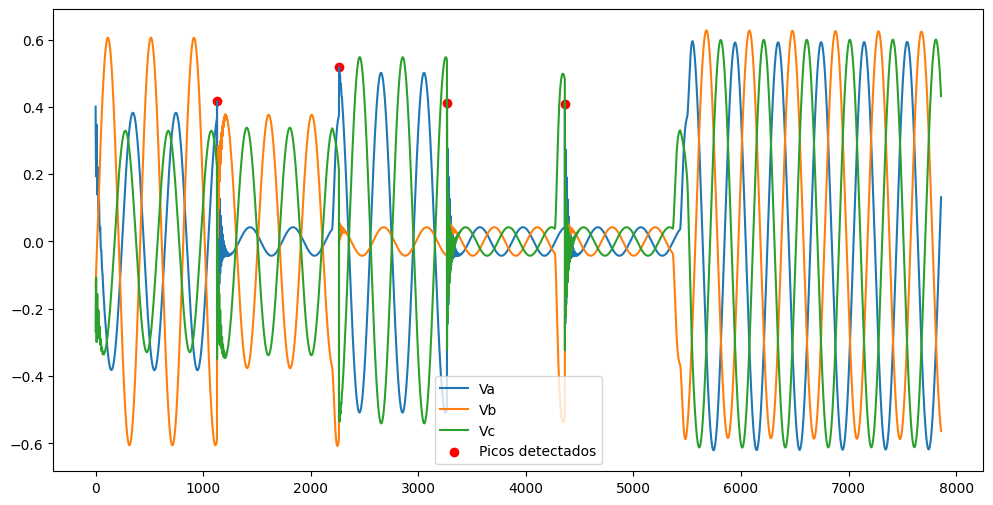

In [19]:
#Visualizar transitorios  

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["Va"], label="Va")
plt.plot(df["Vb"], label="Vb")
plt.plot(df["Vc"], label="Vc")
plt.scatter(df.index[df["Pico_tension"]==1], df["Va"][df["Pico_tension"]==1], color="red", label="Picos detectados")
plt.legend()
plt.show()


### THD (Total Harmonic Distortion)

In [25]:
import numpy as np

# FFT de la señal
fft_Va = np.fft.fft(df["Va"])
magnitudes = np.abs(fft_Va)

# Armónicos de interés
armonicos = [2, 3, 5, 7, 13]

# Fundamental (armónico 1)
fundamental = magnitudes[1]

# Calcular THD
thd_Va = np.sqrt(sum(magnitudes[n]**2 for n in armonicos)) / fundamental

print("THD Va:", thd_Va)


THD Va: 2.0909230730453214


In [26]:
#Criterio de fallo 
# Normal: THD < 5%
#Precaución: 5–8%
#Crítico: > 8%

def fallo_thd(thd, precaucion=0.05, critico=0.08):
    if thd > critico:
        return 2  # crítico
    elif thd > precaucion:
        return 1  # precaución
    else:
        return 0  # normal

df["Fallo_THD_Va"] = fallo_thd(thd_Va)



#### supongamos que la tensión nominal es 1.0 p.u. ( ajustar según al sistema que elija ):

In [27]:
# Definir umbrales
umbral_sag = 0.9   # 90% del nominal
umbral_swell = 1.1 # 110% del nominal

# Detectar sags y swells por fase
df["Sag_A"] = (df["Va"] < umbral_sag).astype(int)
df["Sag_B"] = (df["Vb"] < umbral_sag).astype(int)
df["Sag_C"] = (df["Vc"] < umbral_sag).astype(int)

df["Swell_A"] = (df["Va"] > umbral_swell).astype(int)
df["Swell_B"] = (df["Vb"] > umbral_swell).astype(int)
df["Swell_C"] = (df["Vc"] > umbral_swell).astype(int)

# Columna global: si alguna fase tiene sag o swell
df["Fallo_sagswells"] = (
    df[["Sag_A","Sag_B","Sag_C","Swell_A","Swell_B","Swell_C"]].max(axis=1)
)

# Conteo de registros
print(df["Fallo_sagswells"].value_counts())


Fallo_sagswells
1    7861
Name: count, dtype: int64


#### FACTOR DE DESBALANCE ENTRE FASOS

In [22]:
# Calcular promedio de fases
df["I_avg"] = (df["A"] + df["B"] + df["C"]) / 3

# Calcular desviaciones absolutas respecto al promedio
df["Desv_A"] = abs(df["A"] - df["I_avg"])
df["Desv_B"] = abs(df["B"] - df["I_avg"])
df["Desv_C"] = abs(df["C"] - df["I_avg"])

# Factor de desbalance
df["Factor_desbalance"] = df[["Desv_A","Desv_B","Desv_C"]].max(axis=1) / df["I_avg"]

# Definir fallo si el desbalance supera un umbral (ejemplo 10%)
umbral = 0.1
df["Fallo_desbalance"] = (df["Factor_desbalance"] > umbral).astype(int)

# Conteo de registros
print(df["Fallo_desbalance"].value_counts())


Fallo_desbalance
0    4594
1    3267
Name: count, dtype: int64


#### Factor de potencia (FP)

In [23]:
import numpy as np

# Calcular potencia aparente y activa por fase
df["S_a"] = df["Va"] * df["Ia"]
df["S_b"] = df["Vb"] * df["Ib"]
df["S_c"] = df["Vc"] * df["Ic"]

# Potencia aparente total (magnitud)
df["S_total"] = np.sqrt(df["S_a"]**2 + df["S_b"]**2 + df["S_c"]**2)

# Potencia activa (aprox: producto directo V*I)
df["P_total"] = df["Va"]*df["Ia"] + df["Vb"]*df["Ib"] + df["Vc"]*df["Ic"]

# Factor de potencia
df["Factor_potencia"] = df["P_total"] / df["S_total"]

# Detectar desfase (ejemplo: FP < 0.9)
df["Fallo_FP"] = (df["Factor_potencia"] < 0.9).astype(int)

print(df["Fallo_FP"].value_counts())


Fallo_FP
0    4457
1    3404
Name: count, dtype: int64


### sobre tension seteado en 100A

In [24]:
# Definir umbral de sobrecorriente
umbral_corriente = 100  

# Detectar sobrecorriente en cada fase
df["Sobrecorriente_A"] = (df["Ia"].abs() > umbral_corriente).astype(int)
df["Sobrecorriente_B"] = (df["Ib"].abs() > umbral_corriente).astype(int)
df["Sobrecorriente_C"] = (df["Ic"].abs() > umbral_corriente).astype(int)

# Columna global: si alguna fase supera el umbral
df["Fallo_sobrecorriente"] = (
    df[["Sobrecorriente_A","Sobrecorriente_B","Sobrecorriente_C"]].max(axis=1)
)

# Conteo de registros
print(df["Fallo_sobrecorriente"].value_counts())


Fallo_sobrecorriente
1    5377
0    2484
Name: count, dtype: int64


### servira poner todas estas funciones en un solo bloque ?

### Calcula 8 criterios de fallo (armónicos, tierra, transitorios, desbalance, FP, sobrecorriente, THD, sags/swells).

### Los guarda como columnas binarias (0 = normal, 1 = fallo).

### Agrega una columna Total_fallos que resume cuántos criterios se cumplen en cada registro.

In [28]:
import numpy as np
import pandas as pd

# --- 1. Armónicos (ejemplo con Ia, FFT) ---
fft_Ia = np.fft.fft(df["Ia"])
magnitudes = np.abs(fft_Ia)
armonicos = [2, 3, 5, 7, 13]
fundamental = magnitudes[1]
thd_Ia = np.sqrt(sum(magnitudes[n]**2 for n in armonicos)) / fundamental
df["Fallo_armonicos"] = (thd_Ia > 0.05).astype(int)  # umbral 5%

# --- 2. Descarga a tierra / neutro desplazado ---
df["Suma_fases"] = df["A"] + df["B"] + df["C"]
df["Residuo"] = df["Suma_fases"] - df["G"]
df["Fallo_tierra"] = (df["Residuo"].abs() > 0.1).astype(int)

# --- 3. Picos de tensión (transitorios) ---
df["dVa"] = df["Va"].diff()
df["dVb"] = df["Vb"].diff()
df["dVc"] = df["Vc"].diff()
umbral_pico = 0.5
df["Pico_tension"] = (
    (df["dVa"].abs() > umbral_pico) |
    (df["dVb"].abs() > umbral_pico) |
    (df["dVc"].abs() > umbral_pico)
).astype(int)

# --- 4. Desbalance de fases ---
df["I_avg"] = (df["A"] + df["B"] + df["C"]) / 3
df["Factor_desbalance"] = df[["A","B","C"]].sub(df["I_avg"], axis=0).abs().max(axis=1) / df["I_avg"]
df["Fallo_desbalance"] = (df["Factor_desbalance"] > 0.1).astype(int)

# --- 5. Factor de potencia ---
df["P_total"] = df["Va"]*df["Ia"] + df["Vb"]*df["Ib"] + df["Vc"]*df["Ic"]
df["S_total"] = np.sqrt((df["Va"]*df["Ia"])**2 + (df["Vb"]*df["Ib"])**2 + (df["Vc"]*df["Ic"])**2)
df["Factor_potencia"] = df["P_total"] / df["S_total"]
df["Fallo_FP"] = (df["Factor_potencia"] < 0.9).astype(int)

# --- 6. Sobrecorriente ---
umbral_corriente = 100
df["Fallo_sobrecorriente"] = (
    (df["Ia"].abs() > umbral_corriente) |
    (df["Ib"].abs() > umbral_corriente) |
    (df["Ic"].abs() > umbral_corriente)
).astype(int)

# --- 7. THD (ejemplo con Va) ---
fft_Va = np.fft.fft(df["Va"])
magnitudes_Va = np.abs(fft_Va)
fundamental_Va = magnitudes_Va[1]
thd_Va = np.sqrt(sum(magnitudes_Va[n]**2 for n in armonicos)) / fundamental_Va
df["Fallo_THD"] = (thd_Va > 0.05).astype(int)

# --- 8. Sags/Swells ---
umbral_sag = 0.9
umbral_swell = 1.1
df["Fallo_sagswells"] = (
    (df["Va"] < umbral_sag) | (df["Vb"] < umbral_sag) | (df["Vc"] < umbral_sag) |
    (df["Va"] > umbral_swell) | (df["Vb"] > umbral_swell) | (df["Vc"] > umbral_swell)
).astype(int)

# --- Consolidar ---
fallos_cols = ["Fallo_armonicos","Fallo_tierra","Pico_tension",
               "Fallo_desbalance","Fallo_FP","Fallo_sobrecorriente",
               "Fallo_THD","Fallo_sagswells"]

df["Total_fallos"] = df[fallos_cols].sum(axis=1)


### contador de fallos

In [30]:
# Contar valores de cada criterio de fallo
for col in ["Fallo_armonicos","Fallo_tierra","Pico_tension",
            "Fallo_desbalance","Fallo_FP","Fallo_sobrecorriente",
            "Fallo_THD","Fallo_sagswells"]:
    print(f"{col}:\n", df[col].value_counts(), "\n")


Fallo_armonicos:
 Fallo_armonicos
1    7861
Name: count, dtype: int64 

Fallo_tierra:
 Fallo_tierra
1    4367
0    3494
Name: count, dtype: int64 

Pico_tension:
 Pico_tension
0    7857
1       4
Name: count, dtype: int64 

Fallo_desbalance:
 Fallo_desbalance
0    4594
1    3267
Name: count, dtype: int64 

Fallo_FP:
 Fallo_FP
0    4457
1    3404
Name: count, dtype: int64 

Fallo_sobrecorriente:
 Fallo_sobrecorriente
1    5377
0    2484
Name: count, dtype: int64 

Fallo_THD:
 Fallo_THD
1    7861
Name: count, dtype: int64 

Fallo_sagswells:
 Fallo_sagswells
1    7861
Name: count, dtype: int64 



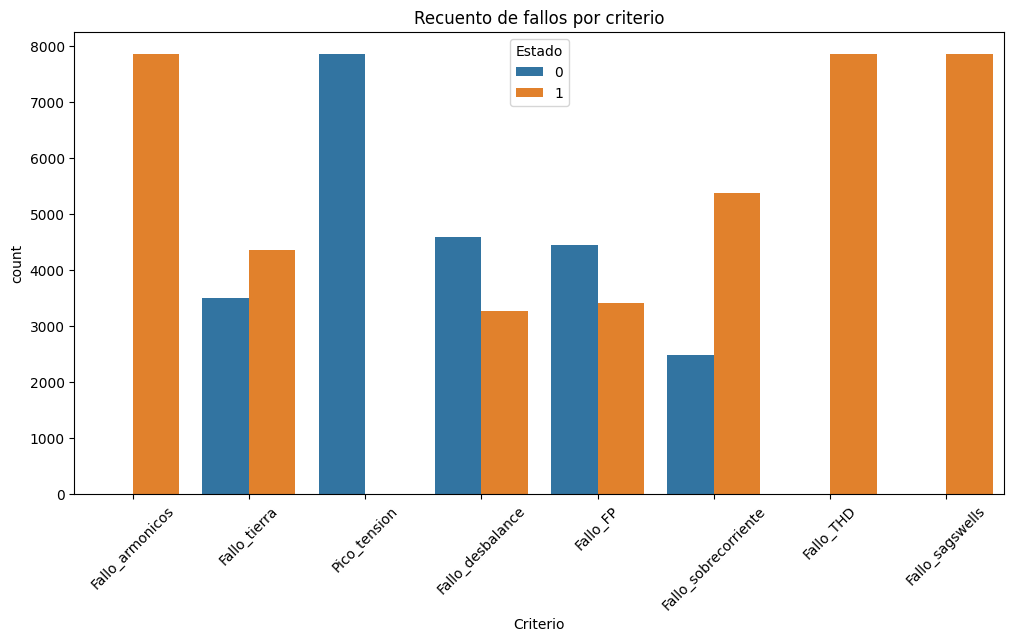

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las columnas de fallos
fallos_cols = ["Fallo_armonicos","Fallo_tierra","Pico_tension",
               "Fallo_desbalance","Fallo_FP","Fallo_sobrecorriente",
               "Fallo_THD","Fallo_sagswells"]

# Reestructuramos el DataFrame
df_melt = df[fallos_cols].melt(var_name="Criterio", value_name="Estado")

# Graficamos
plt.figure(figsize=(12,6))
sns.countplot(x="Criterio", hue="Estado", data=df_melt)
plt.xticks(rotation=45)
plt.title("Recuento de fallos por criterio")
plt.show()


In [33]:
df.columns

Index(['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc',
       'Fallo_armonicos', 'Suma_fases', 'Residuo', 'Fallo_tierra', 'dVa',
       'dVb', 'dVc', 'Pico_tension', 'I_avg', 'Desv_A', 'Desv_B', 'Desv_C',
       'Factor_desbalance', 'Fallo_desbalance', 'S_a', 'S_b', 'S_c', 'S_total',
       'P_total', 'Factor_potencia', 'Fallo_FP', 'Sobrecorriente_A',
       'Sobrecorriente_B', 'Sobrecorriente_C', 'Fallo_sobrecorriente',
       'Fallo_THD_Va', 'Sag_A', 'Sag_B', 'Sag_C', 'Swell_A', 'Swell_B',
       'Swell_C', 'Fallo_sagswells', 'Fallo_THD', 'Total_fallos'],
      dtype='str')

### Recuento de fallos por criterio

In [34]:
fallos_cols = ["Fallo_armonicos","Fallo_tierra","Pico_tension",
               "Fallo_desbalance","Fallo_FP","Fallo_sobrecorriente",
               "Fallo_THD","Fallo_sagswells"]

# Recuento de cada columna
conteos = {col: df[col].value_counts().to_dict() for col in fallos_cols}

# Convertir a DataFrame para ver todo junto
df_conteos = pd.DataFrame(conteos).T.fillna(0).astype(int)
df_conteos.columns = ["No fallo (0)", "Fallo (1)"]
print(df_conteos)


                      No fallo (0)  Fallo (1)
Fallo_armonicos               7861          0
Fallo_tierra                  4367       3494
Pico_tension                     4       7857
Fallo_desbalance              3267       4594
Fallo_FP                      3404       4457
Fallo_sobrecorriente          5377       2484
Fallo_THD                     7861          0
Fallo_sagswells               7861          0


In [36]:
# Lista de columnas de fallos que definimos
failure_cols = ["Fallo_armonicos","Fallo_tierra","Pico_tension",
                "Fallo_desbalance","Fallo_FP","Fallo_sobrecorriente",
                "Fallo_THD","Fallo_sagswells"]

# Función para clasificar tipo de fallo
def classify_failure_type(row):
    for col in failure_cols:
        if row[col] == 1:
            return col   # devuelve el nombre del fallo detectado
    return "Sin fallo"   # si ninguna condición se cumple

# Aplicar la función al DataFrame
df["Failure Type"] = df.apply(classify_failure_type, axis=1)

# Ver recuento de tipos de fallo
print(df["Failure Type"].value_counts())


Failure Type
Fallo_armonicos    7861
Name: count, dtype: int64


In [37]:
#para todos los fallos 
failure_cols = ["Fallo_armonicos","Fallo_tierra","Pico_tension",
                "Fallo_desbalance","Fallo_FP","Fallo_sobrecorriente",
                "Fallo_THD","Fallo_sagswells"]

def classify_failure_type(row):
    for col in failure_cols:
        if row[col] == 1:
            return col   # devuelve el nombre del fallo
    return "Sin fallo"

df["Failure Type"] = df.apply(classify_failure_type, axis=1)

# Recuento de tipos de fallo
print(df["Failure Type"].value_counts())


Failure Type
Fallo_armonicos    7861
Name: count, dtype: int64


### verificacion obtenida 

In [39]:
# verificacion 

# Lista de columnas de fallos
failure_cols = ["Fallo_armonicos","Fallo_tierra","Pico_tension",
                "Fallo_desbalance","Fallo_FP","Fallo_sobrecorriente",
                "Fallo_THD","Fallo_sagswells"]

# Función que clasifica el tipo de fallo
def classify_failure_type(row):
    for col in failure_cols:
        if row[col] == 1:
            return col   # devuelve el nombre del fallo detectado
    return "Sin fallo"   # si no hay ningún fallo

# Aplicar la función al DataFrame
df["Failure Type"] = df.apply(classify_failure_type, axis=1)

# Verificar la nueva columna
print(df["Failure Type"].head())        # muestra las primeras filas
print(df["Failure Type"].value_counts()) # recuento de cada tipo


0    Fallo_armonicos
1    Fallo_armonicos
2    Fallo_armonicos
3    Fallo_armonicos
4    Fallo_armonicos
Name: Failure Type, dtype: str
Failure Type
Fallo_armonicos    7861
Name: count, dtype: int64


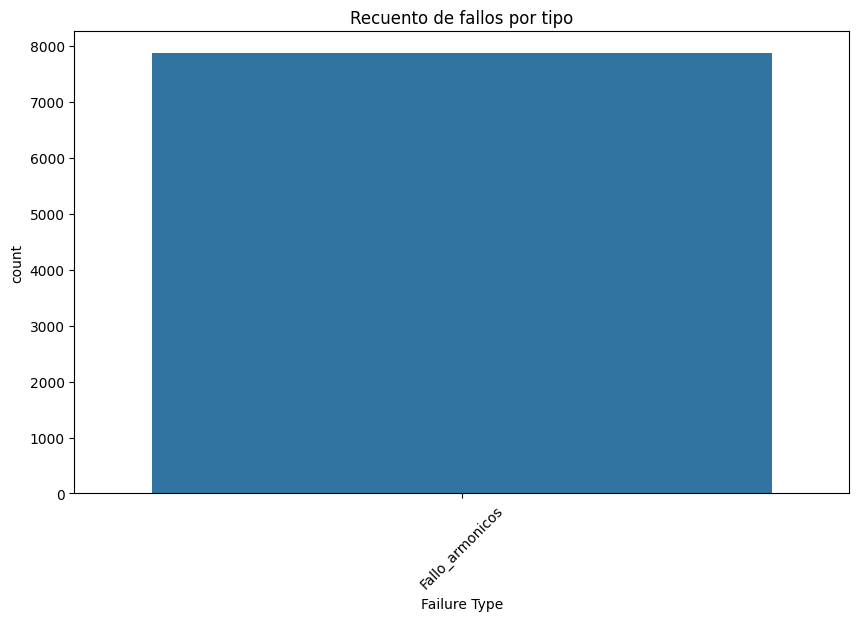

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(x="Failure Type", data=df, order=df["Failure Type"].value_counts().index)
plt.title("Recuento de fallos por tipo")
plt.xticks(rotation=45)
plt.show()


In [42]:
# Verificar si hay fallos en cada criterio
for col in ["Fallo_armonicos","Fallo_tierra","Pico_tension",
            "Fallo_desbalance","Fallo_FP","Fallo_sobrecorriente",
            "Fallo_THD","Fallo_sagswells"]:
    print(col, df[col].sum())


Fallo_armonicos 7861
Fallo_tierra 4367
Pico_tension 4
Fallo_desbalance 3267
Fallo_FP 3404
Fallo_sobrecorriente 5377
Fallo_THD 7861
Fallo_sagswells 7861


In [44]:
# Ejemplo: forzar algunos fallos artificiales
df.loc[0:10, "Fallo_tierra"] = 1
df.loc[20:30, "Fallo_FP"] = 1

print(df["Failure Type"].value_counts())


Failure Type
Fallo_armonicos    7861
Name: count, dtype: int64


In [45]:
failure_cols = ["Fallo_armonicos","Fallo_tierra","Pico_tension",
                "Fallo_desbalance","Fallo_FP","Fallo_sobrecorriente",
                "Fallo_THD","Fallo_sagswells"]

def classify_failure_type(row):
    fallos = [col for col in failure_cols if row[col] == 1]
    if fallos:
        return ", ".join(fallos)   # devuelve todos los fallos separados por coma
    return "Sin fallo"

df["Failure Type"] = df.apply(classify_failure_type, axis=1)

# Ver recuento
print(df["Failure Type"].value_counts())


Failure Type
Fallo_armonicos, Fallo_tierra, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                                2075
Fallo_armonicos, Fallo_FP, Fallo_THD, Fallo_sagswells                                                          1432
Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells    1121
Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells               973
Fallo_armonicos, Fallo_THD, Fallo_sagswells                                                                     922
Fallo_armonicos, Fallo_desbalance, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                   643
Fallo_armonicos, Fallo_desbalance, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                             404
Fallo_armonicos, Fallo_tierra, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                       150
Fallo_armonicos, Fallo_desbalance, Fallo_THD, Fallo_sagswel

### corregimos para que se vean todos los fallos 

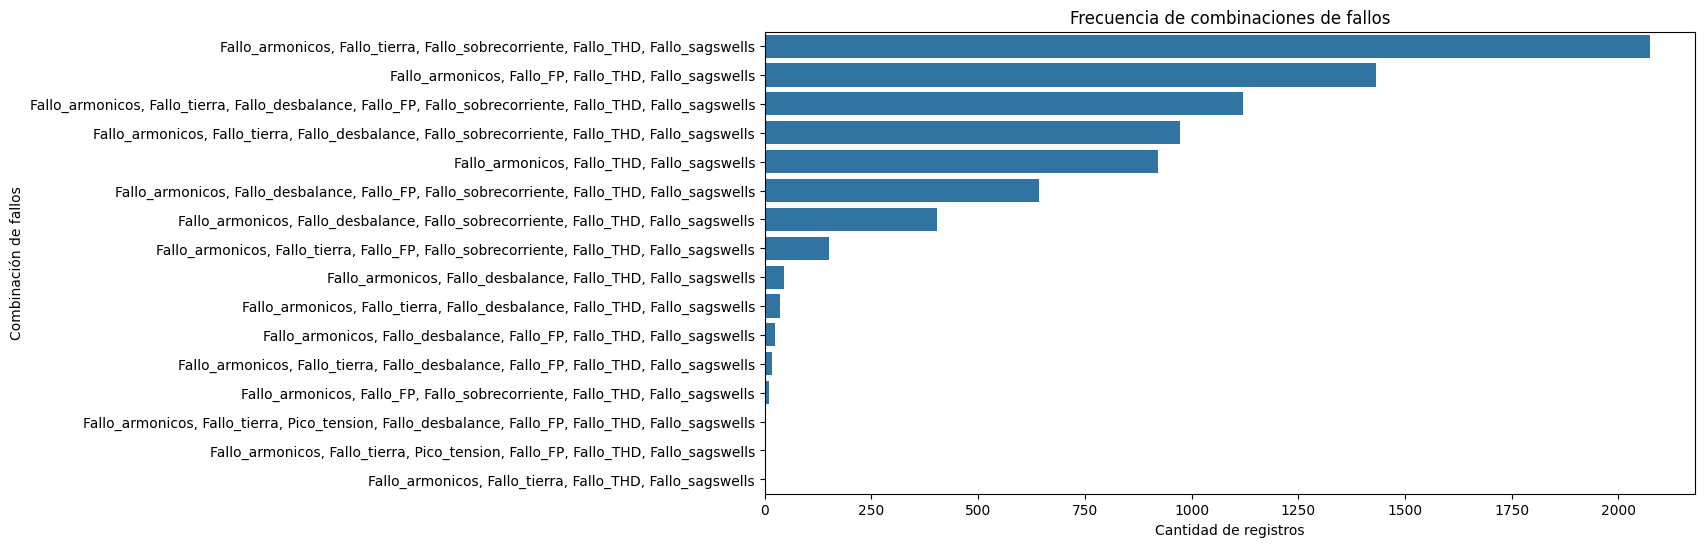

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.countplot(y="Failure Type", data=df, order=df["Failure Type"].value_counts().index)
plt.title("Frecuencia de combinaciones de fallos")
plt.xlabel("Cantidad de registros")
plt.ylabel("Combinación de fallos")
plt.show()


### Como estás calculando armónicos (2, 3, 5, 7, 13) y THD, necesitás que la frecuencia de muestreo sea al menos 20 veces la frecuencia fundamental (regla de Nyquist + margen).

### Para 50 Hz → mínimo ≈ 1 kHz.

### Para ver hasta el armónico 13 → recomendable ≥ 5–10 kHz.

### Para picos de tensión y sags/swells, mientras más alta la frecuencia de muestreo, mejor se capturan los transitorios.

In [48]:
# Supongamos frecuencia de muestreo = 10 kHz
fs = 10000  # Hz
dt = 1/fs   # intervalo entre muestras en segundos

df["Tiempo [s]"] = df.index * dt


### Graficar alguna señal con respecto al tiempo:

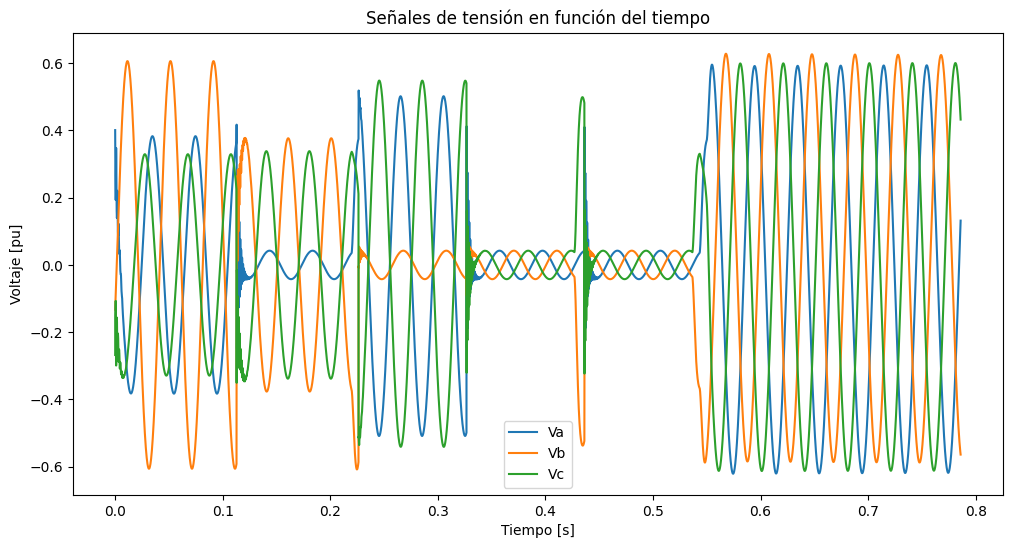

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["Tiempo [s]"], df["Va"], label="Va")
plt.plot(df["Tiempo [s]"], df["Vb"], label="Vb")
plt.plot(df["Tiempo [s]"], df["Vc"], label="Vc")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [pu]")
plt.title("Señales de tensión en función del tiempo")
plt.legend()
plt.show()


In [50]:
df.to_csv("plantilla_fallos.csv", index=False)


### Dispersión con armónicos y fallos

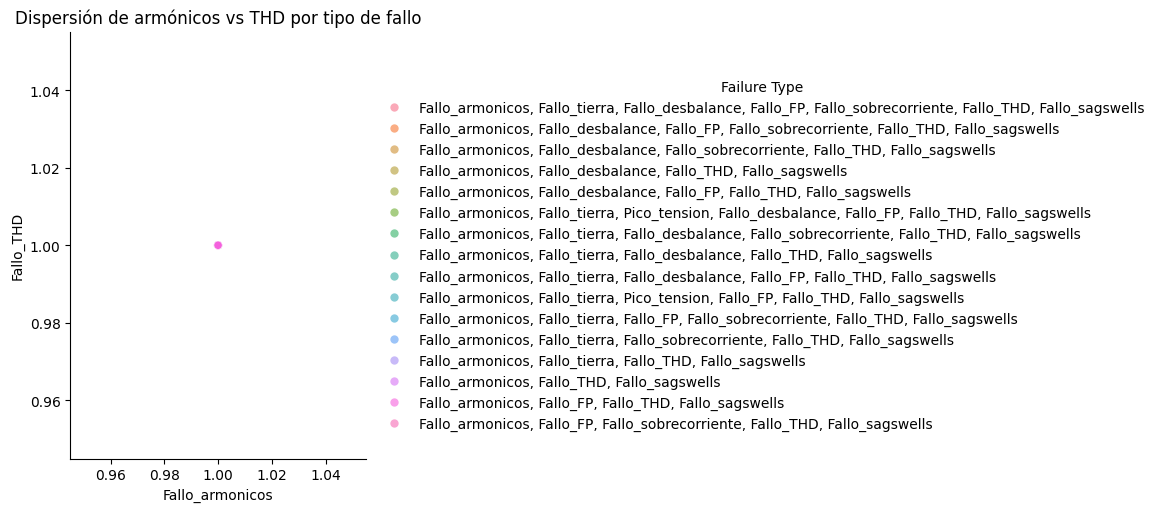

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(
    x="Fallo_armonicos",       # eje X: armónicos
    y="Fallo_THD",             # eje Y: THD
    hue="Failure Type",        # cada combinación de fallos con un color distinto
    data=df,
    alpha=0.6
)

plt.title("Dispersión de armónicos vs THD por tipo de fallo")
plt.show()


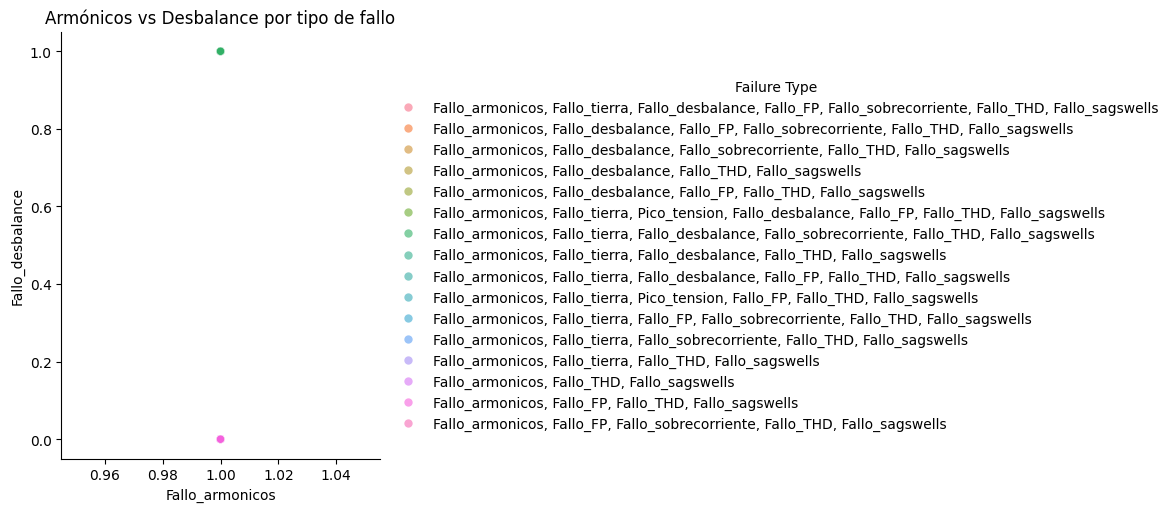

In [52]:
# variante 
sns.relplot(
    x="Fallo_armonicos",
    y="Fallo_desbalance",
    hue="Failure Type",
    data=df,
    alpha=0.6
)
plt.title("Armónicos vs Desbalance por tipo de fallo")
plt.show()


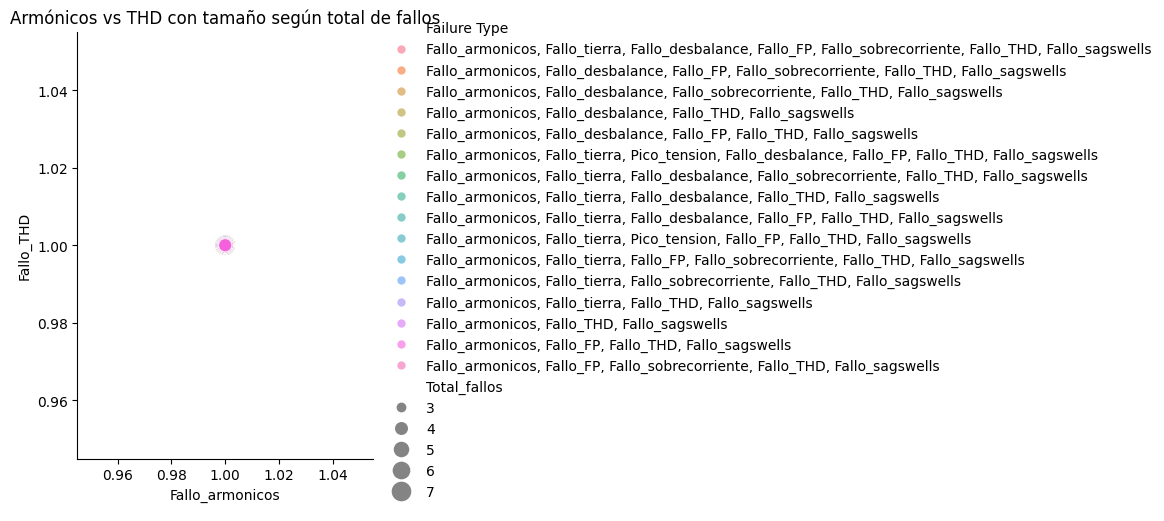

In [53]:
sns.relplot(
    x="Fallo_armonicos",
    y="Fallo_THD",
    hue="Failure Type",
    size="Total_fallos",   # tamaño proporcional al número de fallos
    sizes=(50, 200),
    data=df,
    alpha=0.6
)
plt.title("Armónicos vs THD con tamaño según total de fallos")
plt.show()


In [54]:
df["Failure Type"].unique()  #esto verifica que se valida la columna de errores
# en los colores apuntan a fallos por ejemplo PWF corte de energia 

<StringArray>
['Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells',
               'Fallo_armonicos, Fallo_desbalance, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells',
                         'Fallo_armonicos, Fallo_desbalance, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells',
                                               'Fallo_armonicos, Fallo_desbalance, Fallo_THD, Fallo_sagswells',
                                     'Fallo_armonicos, Fallo_desbalance, Fallo_FP, Fallo_THD, Fallo_sagswells',
         'Fallo_armonicos, Fallo_tierra, Pico_tension, Fallo_desbalance, Fallo_FP, Fallo_THD, Fallo_sagswells',
           'Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells',
                                 'Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_THD, Fallo_sagswells',
                       'Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_FP, Fallo_T

### contrastar fallos entre si 

<Axes: xlabel='Fallo_tierra', ylabel='Fallo_desbalance'>

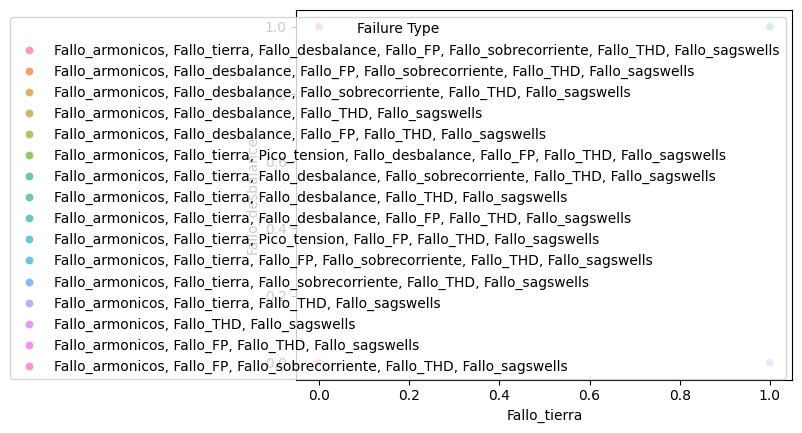

In [56]:
sns.scatterplot(
    x="Fallo_tierra",
    y="Fallo_desbalance",
    hue="Failure Type",
    data=df,
    alpha=0.7
)


##### hay que hacer un reajuste delos graficos de las muetsras con respecto al tiempo de tomade muestra 

##### dentificar patrones dominantes

In [57]:
# Recuento de combinaciones de fallos
failure_counts = df["Failure Type"].value_counts()

print(failure_counts.head(10))  # Top 10 combinaciones


Failure Type
Fallo_armonicos, Fallo_tierra, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                                2075
Fallo_armonicos, Fallo_FP, Fallo_THD, Fallo_sagswells                                                          1432
Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells    1121
Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells               973
Fallo_armonicos, Fallo_THD, Fallo_sagswells                                                                     922
Fallo_armonicos, Fallo_desbalance, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                   643
Fallo_armonicos, Fallo_desbalance, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                             404
Fallo_armonicos, Fallo_tierra, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                       150
Fallo_armonicos, Fallo_desbalance, Fallo_THD, Fallo_sagswel

#### Detectar combinaciones raras

In [58]:
# Combinaciones poco frecuentes
rare_failures = df["Failure Type"].value_counts().tail(10)
print(rare_failures)


Failure Type
Fallo_armonicos, Fallo_desbalance, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                    404
Fallo_armonicos, Fallo_tierra, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells              150
Fallo_armonicos, Fallo_desbalance, Fallo_THD, Fallo_sagswells                                           46
Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_THD, Fallo_sagswells                             35
Fallo_armonicos, Fallo_desbalance, Fallo_FP, Fallo_THD, Fallo_sagswells                                 25
Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_FP, Fallo_THD, Fallo_sagswells                   18
Fallo_armonicos, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                             11
Fallo_armonicos, Fallo_tierra, Pico_tension, Fallo_desbalance, Fallo_FP, Fallo_THD, Fallo_sagswells      2
Fallo_armonicos, Fallo_tierra, Pico_tension, Fallo_FP, Fallo_THD, Fallo_sagswells                        2
Fallo_armonicos, Fallo_t

#### Usar como etiqueta de clasificación

In [59]:
from sklearn.preprocessing import LabelEncoder

# Codificar las combinaciones de fallos como números
encoder = LabelEncoder()
df["Failure_Label"] = encoder.fit_transform(df["Failure Type"])

print(df[["Failure Type", "Failure_Label"]].head())


                                        Failure Type  Failure_Label
0  Fallo_armonicos, Fallo_tierra, Fallo_desbalanc...             10
1  Fallo_armonicos, Fallo_tierra, Fallo_desbalanc...             10
2  Fallo_armonicos, Fallo_tierra, Fallo_desbalanc...             10
3  Fallo_armonicos, Fallo_tierra, Fallo_desbalanc...             10
4  Fallo_armonicos, Fallo_tierra, Fallo_desbalanc...             10


##### Diccionario de mapeo entre combinaciones y etiquetas numéricas



In [60]:
label_map = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print(label_map)

{'Fallo_armonicos, Fallo_FP, Fallo_THD, Fallo_sagswells': np.int64(0), 'Fallo_armonicos, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells': np.int64(1), 'Fallo_armonicos, Fallo_THD, Fallo_sagswells': np.int64(2), 'Fallo_armonicos, Fallo_desbalance, Fallo_FP, Fallo_THD, Fallo_sagswells': np.int64(3), 'Fallo_armonicos, Fallo_desbalance, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells': np.int64(4), 'Fallo_armonicos, Fallo_desbalance, Fallo_THD, Fallo_sagswells': np.int64(5), 'Fallo_armonicos, Fallo_desbalance, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells': np.int64(6), 'Fallo_armonicos, Fallo_tierra, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells': np.int64(7), 'Fallo_armonicos, Fallo_tierra, Fallo_THD, Fallo_sagswells': np.int64(8), 'Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_FP, Fallo_THD, Fallo_sagswells': np.int64(9), 'Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells': np.int64

In [61]:
df["Failure Type"].value_counts().head(10)


Failure Type
Fallo_armonicos, Fallo_tierra, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                                2075
Fallo_armonicos, Fallo_FP, Fallo_THD, Fallo_sagswells                                                          1432
Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells    1121
Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells               973
Fallo_armonicos, Fallo_THD, Fallo_sagswells                                                                     922
Fallo_armonicos, Fallo_desbalance, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                   643
Fallo_armonicos, Fallo_desbalance, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                             404
Fallo_armonicos, Fallo_tierra, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                       150
Fallo_armonicos, Fallo_desbalance, Fallo_THD, Fallo_sagswel

In [62]:
df["Failure Type"].value_counts().tail(10)


Failure Type
Fallo_armonicos, Fallo_desbalance, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                    404
Fallo_armonicos, Fallo_tierra, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells              150
Fallo_armonicos, Fallo_desbalance, Fallo_THD, Fallo_sagswells                                           46
Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_THD, Fallo_sagswells                             35
Fallo_armonicos, Fallo_desbalance, Fallo_FP, Fallo_THD, Fallo_sagswells                                 25
Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_FP, Fallo_THD, Fallo_sagswells                   18
Fallo_armonicos, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                             11
Fallo_armonicos, Fallo_tierra, Pico_tension, Fallo_desbalance, Fallo_FP, Fallo_THD, Fallo_sagswells      2
Fallo_armonicos, Fallo_tierra, Pico_tension, Fallo_FP, Fallo_THD, Fallo_sagswells                        2
Fallo_armonicos, Fallo_t

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Features: todas las columnas numéricas excepto las etiquetas
X = df.drop(columns=["Failure Type", "Failure_Label"])
y = df["Failure_Label"]

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluación
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       437
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00       278
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00       212
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00       119
           7       1.00      1.00      1.00        44
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         6
          10       0.99      1.00      1.00       340
          11       1.00      1.00      1.00        12
          12       1.00      1.00      1.00       299
          13       1.00      1.00      1.00       583
          15       0.00      0.00      0.00         2

    accuracy                           1.00      2359
   macro avg       0.93      0.93      0.93      2359
weighted avg       1.00   

c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

##### Deteccion de fallos 

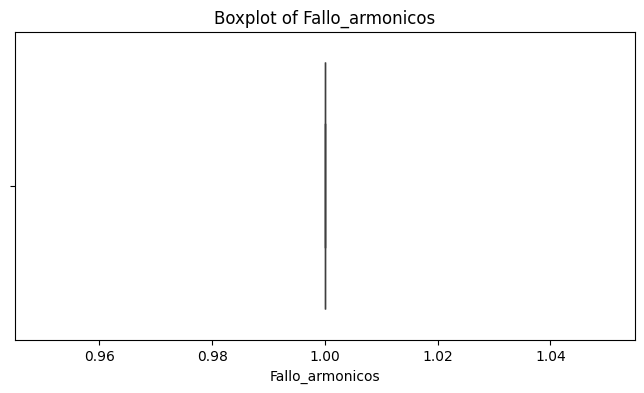

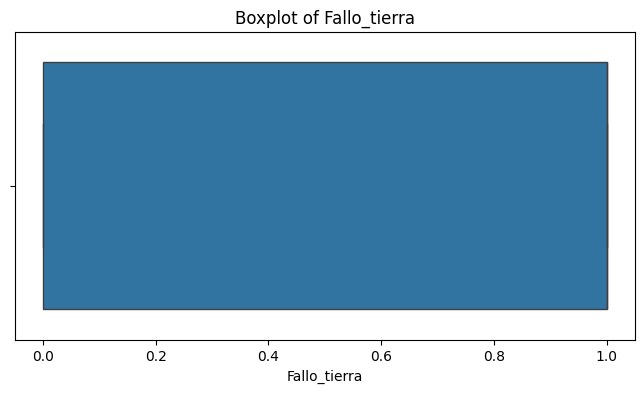

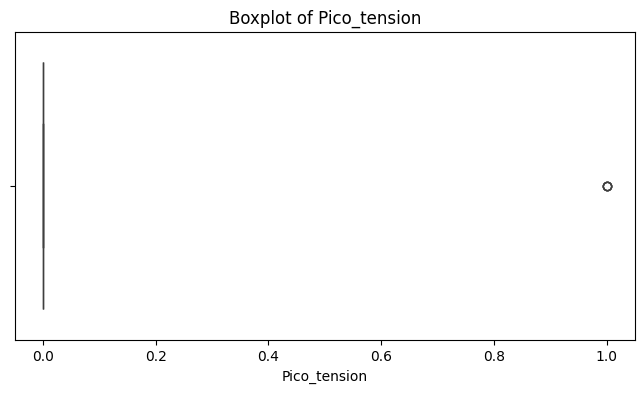

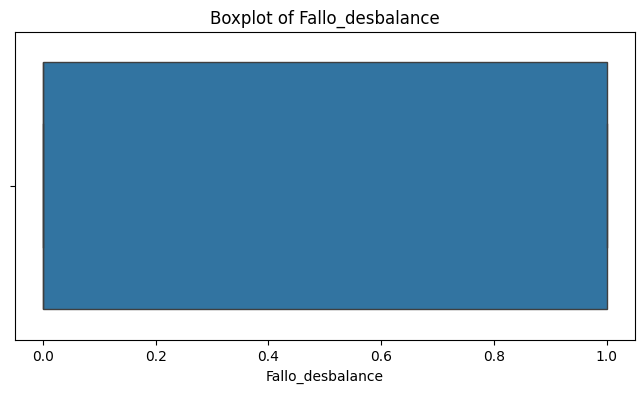

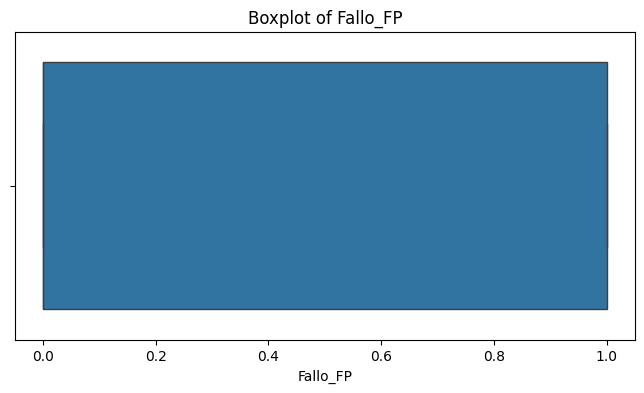

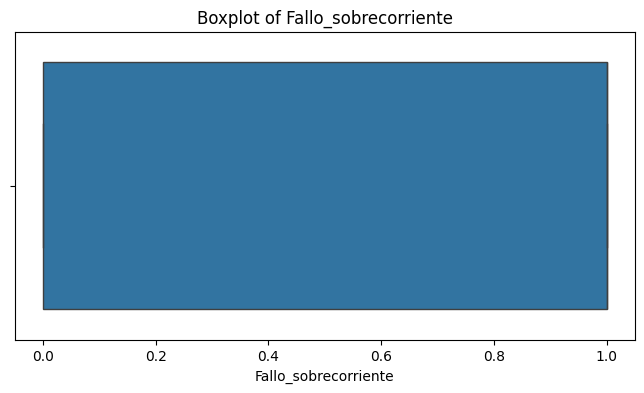

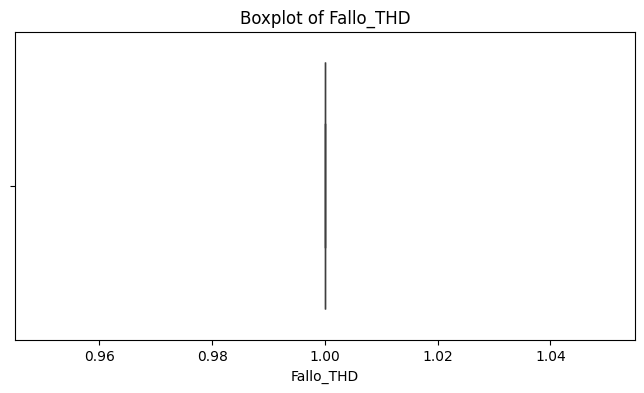

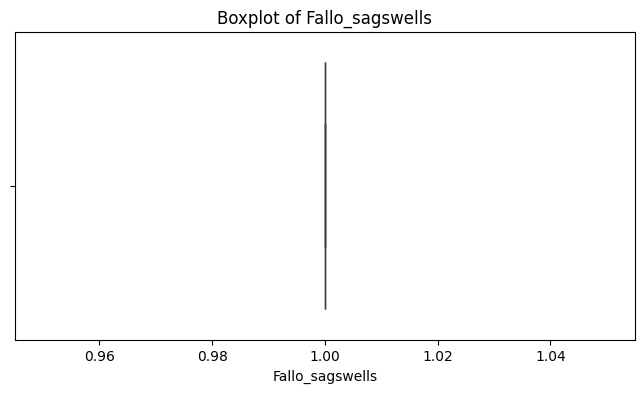

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lista de columnas de fallos
failure_cols = ["Fallo_armonicos","Fallo_tierra","Pico_tension",
                "Fallo_desbalance","Fallo_FP","Fallo_sobrecorriente",
                "Fallo_THD","Fallo_sagswells"]

# Generar boxplots para cada fallo
for col in failure_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


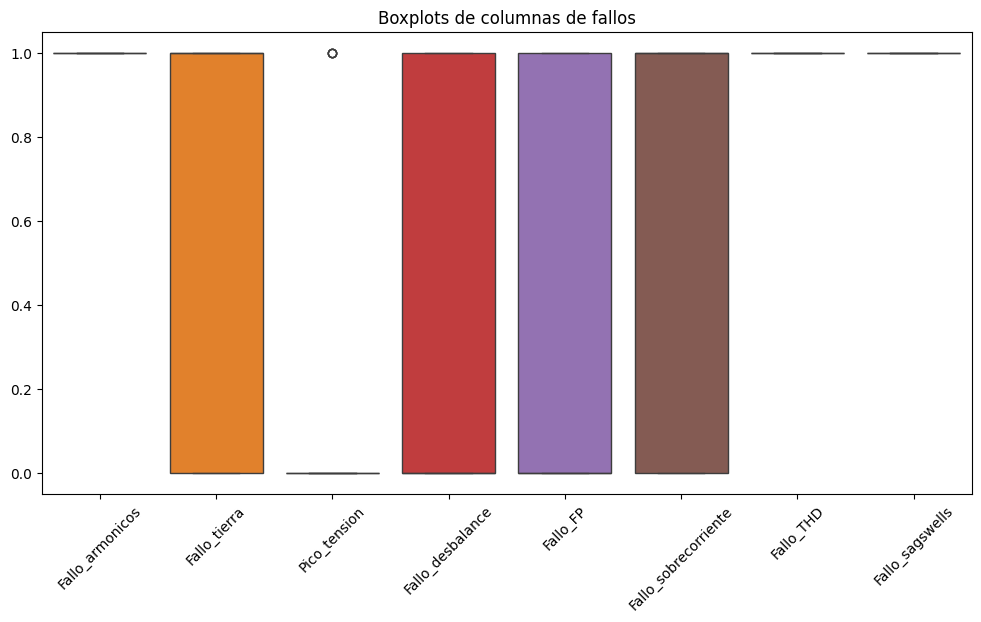

In [66]:
# variante de la misma funcion 
plt.figure(figsize=(12,6))
sns.boxplot(data=df[failure_cols])
plt.title("Boxplots de columnas de fallos")
plt.xticks(rotation=45)
plt.show()


### ingenieria de caracteristica y aprendizaje AUTOOMATICO 


In [67]:
df.columns 

Index(['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc',
       'Fallo_armonicos', 'Suma_fases', 'Residuo', 'Fallo_tierra', 'dVa',
       'dVb', 'dVc', 'Pico_tension', 'I_avg', 'Desv_A', 'Desv_B', 'Desv_C',
       'Factor_desbalance', 'Fallo_desbalance', 'S_a', 'S_b', 'S_c', 'S_total',
       'P_total', 'Factor_potencia', 'Fallo_FP', 'Sobrecorriente_A',
       'Sobrecorriente_B', 'Sobrecorriente_C', 'Fallo_sobrecorriente',
       'Fallo_THD_Va', 'Sag_A', 'Sag_B', 'Sag_C', 'Swell_A', 'Swell_B',
       'Swell_C', 'Fallo_sagswells', 'Fallo_THD', 'Total_fallos',
       'Failure Type', 'Tiempo [s]', 'Failure_Label'],
      dtype='str')

In [69]:
sensor_cols = ['G','C','B','A','Ia','Ib','Ic','Va','Vb','Vc',
               'Suma_fases','Residuo','dVa','dVb','dVc','I_avg',
               'Desv_A','Desv_B','Desv_C','Factor_desbalance',
               'S_a','S_b','S_c','S_total','P_total','Factor_potencia',
               'Sobrecorriente_A','Sobrecorriente_B','Sobrecorriente_C',
               'Sag_A','Sag_B','Sag_C','Swell_A','Swell_B','Swell_C']

failure_cols = ['Fallo_armonicos','Fallo_tierra','Pico_tension',
                'Fallo_desbalance','Fallo_FP','Fallo_sobrecorriente',
                'Fallo_THD_Va','Fallo_sagswells','Fallo_THD',
                'Total_fallos','Failure Type','Failure_Label']


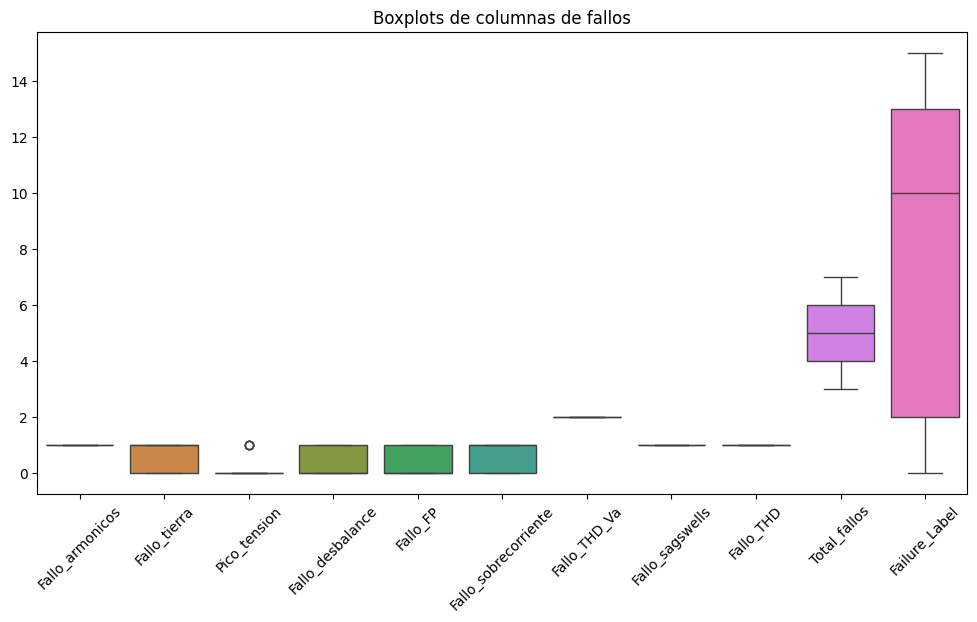

In [70]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[failure_cols])
plt.title("Boxplots de columnas de fallos")
plt.xticks(rotation=45)
plt.show()


In [71]:
df["Failure Type"].value_counts().head(10)


Failure Type
Fallo_armonicos, Fallo_tierra, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                                2075
Fallo_armonicos, Fallo_FP, Fallo_THD, Fallo_sagswells                                                          1432
Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells    1121
Fallo_armonicos, Fallo_tierra, Fallo_desbalance, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells               973
Fallo_armonicos, Fallo_THD, Fallo_sagswells                                                                     922
Fallo_armonicos, Fallo_desbalance, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                   643
Fallo_armonicos, Fallo_desbalance, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                             404
Fallo_armonicos, Fallo_tierra, Fallo_FP, Fallo_sobrecorriente, Fallo_THD, Fallo_sagswells                       150
Fallo_armonicos, Fallo_desbalance, Fallo_THD, Fallo_sagswel

In [75]:
# Total de fallos por fila
df['Total_fallos_calc'] = df[['Fallo_armonicos','Fallo_tierra','Pico_tension',
                              'Fallo_desbalance','Fallo_FP','Fallo_sobrecorriente',
                              'Fallo_THD','Fallo_sagswells']].sum(axis=1)


In [76]:
#CODEAR UNA COLUMNA CATEGORICA 

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Failure_Label'] = encoder.fit_transform(df['Failure Type'])


In [77]:
print(df.dtypes)


G                         int64
C                         int64
B                         int64
A                         int64
Ia                      float64
Ib                      float64
Ic                      float64
Va                      float64
Vb                      float64
Vc                      float64
Fallo_armonicos           int64
Suma_fases                int64
Residuo                   int64
Fallo_tierra              int64
dVa                     float64
dVb                     float64
dVc                     float64
Pico_tension              int64
I_avg                   float64
Desv_A                  float64
Desv_B                  float64
Desv_C                  float64
Factor_desbalance       float64
Fallo_desbalance          int64
S_a                     float64
S_b                     float64
S_c                     float64
S_total                 float64
P_total                 float64
Factor_potencia         float64
Fallo_FP                  int64
Sobrecor

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Features: todas las columnas numéricas excepto las etiquetas
X = df.drop(columns=["Failure Type", "Failure_Label"])
y = df["Failure_Label"]

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

# Evaluación
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       437
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00       278
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00       212
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00       119
           7       1.00      1.00      1.00        44
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         6
          10       0.99      1.00      1.00       340
          11       1.00      1.00      1.00        12
          12       1.00      1.00      1.00       299
          13       1.00      1.00      1.00       583
          15       0.00      0.00      0.00         2

    accuracy                           1.00      2359
   macro avg       0.93      0.93      0.93      2359
weighted avg       1.00   

c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

##### armar un flujo modular de entrenamiento y evaluación que te permita:

##### Preparar los datos (features y etiquetas).

##### Entrenar un modelo (ej. RandomForest).

##### Evaluar resultados (classification report + matriz de confusión).

##### Analizar importancia de variables (qué sensores/fallos aportan más a la predicción).

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Preparación de datos
X = df.drop(columns=["Failure Type", "Failure_Label"])  # todas las columnas numéricas
y = df["Failure_Label"]                                # etiqueta codificada






In [80]:
# 2. División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Entrenamiento del modelo
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

# 4. Evaluación
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       437
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00       278
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00       212
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00       119
           7       1.00      1.00      1.00        44
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         6
          10       0.99      1.00      1.00       340
          11       1.00      1.00      1.00        12
          12       1.00      1.00      1.00       299
          13       1.00      1.00      1.00       583
          15       0.00      0.00      0.00         2

    accuracy                           1.00      2359
   macro avg       0.93      0.93      0.93      2359
weighted avg       1.00   

c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

##### CARGAR DATOS PARA APRENDIZAJE DE MAQUINA 

In [85]:
# Cargar paquetes de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Features: seleccionamos sensores y variables numéricas
feature_cols = ['G','C','B','A','Ia','Ib','Ic','Va','Vb','Vc',
                'Suma_fases','Residuo','dVa','dVb','dVc','I_avg',
                'Desv_A','Desv_B','Desv_C','Factor_desbalance',
                'S_a','S_b','S_c','S_total','P_total','Factor_potencia',
                'Sobrecorriente_A','Sobrecorriente_B','Sobrecorriente_C',
                'Sag_A','Sag_B','Sag_C','Swell_A','Swell_B','Swell_C',
                'Total_fallos_calc']   # tu columna calculada

Xfeatures = df[feature_cols]
ylabels = df['Failure_Label']   # etiquetas codificadas

# Split: entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(Xfeatures, ylabels, test_size=0.3, random_state=42)

# Modelo Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

# Evaluación
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       437
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00       278
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00       212
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00       119
           7       1.00      1.00      1.00        44
           8       0.00      0.00      0.00         1
           9       1.00      1.00      1.00         6
          10       0.99      1.00      1.00       340
          11       1.00      1.00      1.00        12
          12       1.00      1.00      1.00       299
          13       1.00      1.00      1.00       583
          15       0.00      0.00      0.00         2

    accuracy                           1.00      2359
   macro avg       0.87      0.87      0.87      2359
weighted avg       1.00   

c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

<Figure size 1200x800 with 0 Axes>

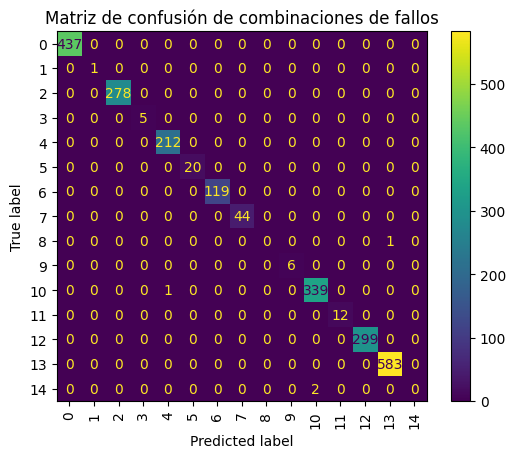

In [87]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear figura con tamaño definido
plt.figure(figsize=(12,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation=90)   # solo rotación de etiquetas
plt.title("Matriz de confusión de combinaciones de fallos")
plt.show()


In [88]:
# LO MISMO PERO CON OTRA FORMA 
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def build_model(classifier, x_train, y_train, x_test, y_test):
    classifier.fit(x_train, y_train)
    y_pred = classifier.predict(x_test)
    print("Accuracy:", classifier.score(x_test, y_test))
    print(classification_report(y_test, y_pred))
    
    # Matriz de confusión con etiquetas y rotación
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12,8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
    disp.plot(xticks_rotation=90)
    plt.title("Matriz de confusión de combinaciones de fallos")
    plt.show()
    
    return classifier


<Figure size 1200x800 with 0 Axes>

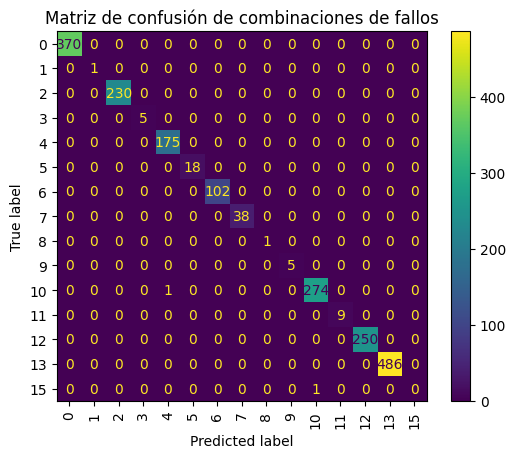

Accuracy: 0.9989827060020345
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       370
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00       230
           3       1.00      1.00      1.00         5
           4       0.99      1.00      1.00       175
           5       1.00      1.00      1.00        18
           6       1.00      1.00      1.00       102
           7       1.00      1.00      1.00        38
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00       275
          11       1.00      1.00      1.00         9
          12       1.00      1.00      1.00       250
          13       1.00      1.00      1.00       486
          15       0.00      0.00      0.00         1

    accuracy                           1.00      1966
   macro avg       0.93      0.93      0.93      19

c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(Xfeatures, ylabels, test_size=0.25, random_state=42)

# Modelo Random Forest adaptado
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf_clf = rf.fit(X_train, y_train)

# MATRIX DE CONFUSION 
import numpy as np

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,8))

# Usamos las clases presentes en y_test
labels = np.unique(y_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=90)
plt.title("Matriz de confusión de combinaciones de fallos")
plt.show()


# Evaluación
y_pred = rf_clf.predict(X_test)
print("Accuracy:", rf_clf.score(X_test, y_test))
print(classification_report(y_test, y_pred))


# Importancia de variables
importances = rf_clf.feature_importances_
feat_importances = sorted(zip(Xfeatures.columns, importances), key=lambda x: x[1], reverse=True)

print("Top 10 variables más importantes:")
for f, imp in feat_importances[:10]:
    print(f"{f}: {imp:.4f}")


##### Interpretación de resultados
##### Clases frecuentes (ej. 0, 2, 4, 10, 12, 13) → todas con precisión y recall perfectos.

##### Clases raras (ej. 1, 8, 9, 15) → aparecen muy pocas veces en el dataset.

##### Por eso en label 15 el modelo no predijo ningún caso → precision = 0.00.

##### Esto genera el UndefinedMetricWarning.
##### No es un error grave, simplemente indica que el modelo no tuvo suficientes ejemplos para aprender esa clase.

C:\Users\Cristina\AppData\Local\Temp\ipykernel_11260\1333192177.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importancia", y="Variable", data=top10, palette="viridis")


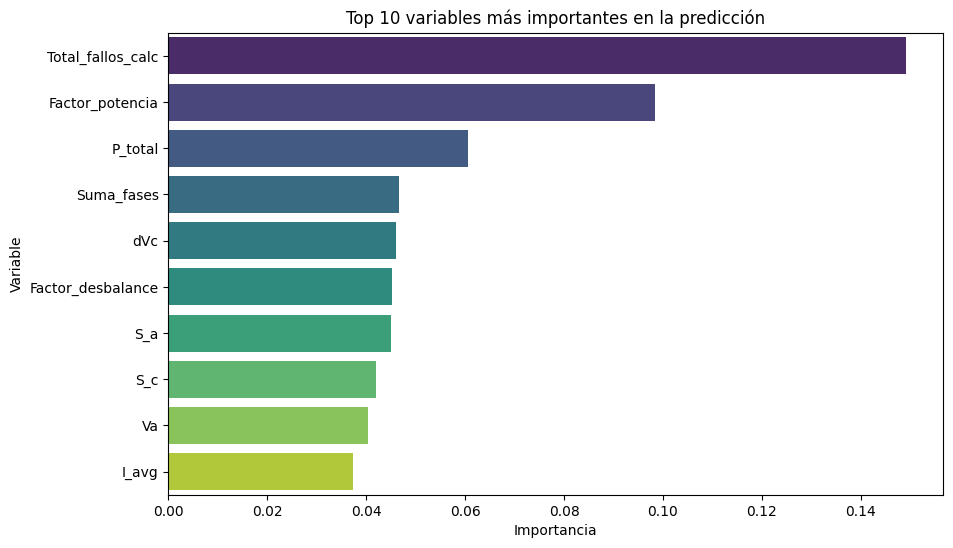

In [91]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convertir a DataFrame
feat_importances_df = pd.DataFrame(feat_importances, columns=["Variable","Importancia"])

# Seleccionar top 10
top10 = feat_importances_df.head(10)

# Graficar
plt.figure(figsize=(10,6))
sns.barplot(x="Importancia", y="Variable", data=top10, palette="viridis")
plt.title("Top 10 variables más importantes en la predicción")
plt.show()


#### afinar la presicion del modelo 

In [94]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Imputación de NaN con la media de cada columna
imputer = SimpleImputer(strategy="mean")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Modelo Random Forest (puede usar X_train, X_test originales)
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf_clf = rf.fit(X_train, y_train)
print("Accuracy (Random Forest):", rf_clf.score(X_test, y_test))

# Modelo Logistic Regression (usa datos imputados)
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_reg.fit(X_train_imp, y_train)
print("Accuracy (Logistic Regression):", log_reg.score(X_test_imp, y_test))

# Reporte comparativo
y_pred_rf = rf_clf.predict(X_test)
y_pred_log = log_reg.predict(X_test_imp)

print("\n--- Random Forest ---")
print(classification_report(y_test, y_pred_rf))

print("\n--- Logistic Regression ---")
print(classification_report(y_test, y_pred_log))


Accuracy (Random Forest): 0.9989827060020345


c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy (Logistic Regression): 0.9857578840284842

--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       370
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00       230
           3       1.00      1.00      1.00         5
           4       0.99      1.00      1.00       175
           5       1.00      1.00      1.00        18
           6       1.00      1.00      1.00       102
           7       1.00      1.00      1.00        38
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00       275
          11       1.00      1.00      1.00         9
          12       1.00      1.00      1.00       250
          13       1.00      1.00      1.00       486
          15       0.00      0.00      0.00         1

    accuracy                           1.00      1966
   mac

c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

#### ESCALAMOS LOS DATOS 

In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

log_reg = LogisticRegression(max_iter=5000, random_state=42, class_weight="balanced")
log_reg.fit(X_train_scaled, y_train)
print("Accuracy (Logistic Regression, escalado):", log_reg.score(X_test_scaled, y_test))


Accuracy (Logistic Regression, escalado): 0.9989827060020345


#####  gráfico comparativo de accuracy para visualizar la diferencia entre ambos modelos:

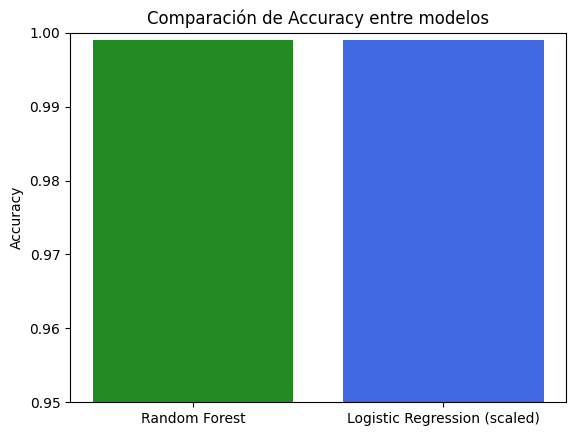

In [96]:
import matplotlib.pyplot as plt

models = ["Random Forest", "Logistic Regression (scaled)"]
accuracies = [rf_clf.score(X_test, y_test), log_reg.score(X_test_scaled, y_test)]

plt.bar(models, accuracies, color=["forestgreen","royalblue"])
plt.ylim(0.95,1.0)
plt.title("Comparación de Accuracy entre modelos")
plt.ylabel("Accuracy")
plt.show()


### antes evaluacion del modelo

In [97]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Features y labels adaptados
feature_cols = ['G','C','B','A','Ia','Ib','Ic','Va','Vb','Vc',
                'Suma_fases','Residuo','dVa','dVb','dVc','I_avg',
                'Desv_A','Desv_B','Desv_C','Factor_desbalance',
                'S_a','S_b','S_c','S_total','P_total','Factor_potencia',
                'Sobrecorriente_A','Sobrecorriente_B','Sobrecorriente_C',
                'Sag_A','Sag_B','Sag_C','Swell_A','Swell_B','Swell_C',
                'Total_fallos_calc']

Xfeatures = df[feature_cols]
ylabels = df['Failure_Label']   # etiqueta codificada

# Split: entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(Xfeatures, ylabels, test_size=0.25, random_state=42)

# Entrenar modelo Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf_clf.fit(X_train, y_train)

# Predicciones
y_pred = rf_clf.predict(X_test)

# Informe de clasificación
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       370
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00       230
           3       1.00      1.00      1.00         5
           4       0.99      1.00      1.00       175
           5       1.00      1.00      1.00        18
           6       1.00      1.00      1.00       102
           7       1.00      1.00      1.00        38
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00       275
          11       1.00      1.00      1.00         9
          12       1.00      1.00      1.00       250
          13       1.00      1.00      1.00       486
          15       0.00      0.00      0.00         1

    accuracy                           1.00      1966
   macro avg       0.93      0.93      0.93      1966
weighted avg       1.00   

c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cristina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

#### la matriz de confusión

In [98]:
import numpy as np
labels = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)


<Figure size 1200x800 with 0 Axes>

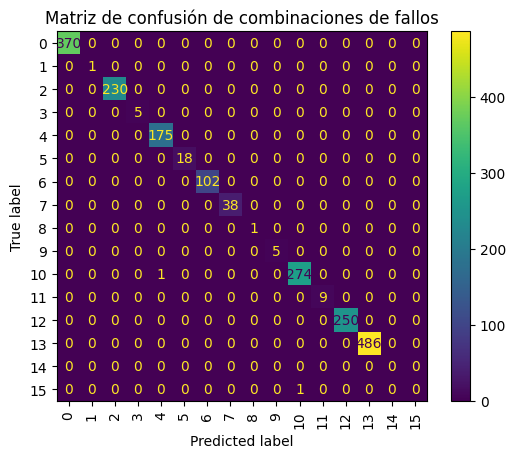

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matriz de confusión con todas las clases conocidas por el modelo
cm = confusion_matrix(y_test, y_pred, labels=rf_clf.classes_)

plt.figure(figsize=(12,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_clf.classes_)
disp.plot(xticks_rotation=90)
plt.title("Matriz de confusión de combinaciones de fallos")
plt.show()


#### GENERAMOS UNA MATRIX BINARIA 

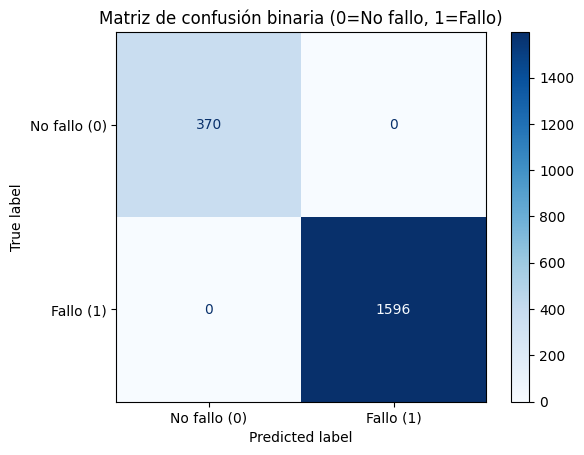

In [100]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Reagrupar etiquetas: 0 = no fallo, 1 = fallo
y_test_bin = np.where(y_test == 0, 0, 1)
y_pred_bin = np.where(y_pred == 0, 0, 1)

# Matriz de confusión binaria
cm_bin = confusion_matrix(y_test_bin, y_pred_bin, labels=[0,1])
disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=["No fallo (0)", "Fallo (1)"])
disp_bin.plot(cmap="Blues")
plt.title("Matriz de confusión binaria (0=No fallo, 1=Fallo)")
plt.show()
